In [ ]:
import marimo as mo
import pandas as pd
from pandas import Series, DataFrame

##Read in the scores file (sat-scores.csv). This time, you want the following columns: Year, State.Code, Total.Math, Family Income.Less than 20k.Math, Family Income.Between 20-40k.Math, Family Income.Between 40-60k.Math, Family Income.Between 60-80k.Math, Family Income.Between 80-100k.Math, and Family Income.More than 100k.Math.

## Rename the income-related column names to something shorter. I recommend income<20k, 20k<income<40k, 40k<income<60k, 60k<income<80k, 80k<income 100k, and income>100k.

In [ ]:
_df = pd.read_csv(
    '/home/peti/Documents/Pandas_workout/data/sat-scores.csv',
    usecols=[
    "Year",
    "State.Code",
    "Total.Math",
    "Family Income.Less than 20k.Math",
    "Family Income.Between 20-40k.Math",
    "Family Income.Between 40-60k.Math",
    "Family Income.Between 60-80k.Math",
    "Family Income.Between 80-100k.Math",
    "Family Income.More than 100k.Math"
    ]
)

# Rename the columns
df = _df.rename(columns={
    "Year": "Year",
    "State.Code": "State_Code",
    "Total.Math": "Total_Math",
    "Family Income.Less than 20k.Math": "income<20k",
    "Family Income.Between 20-40k.Math": "20k<income<40k",
    "Family Income.Between 40-60k.Math": "40k<income<60k",
    "Family Income.Between 60-80k.Math": "60k<income<80k",
    "Family Income.Between 80-100k.Math": "80k<income<100k",
    "Family Income.More than 100k.Math": "income>100k"
})

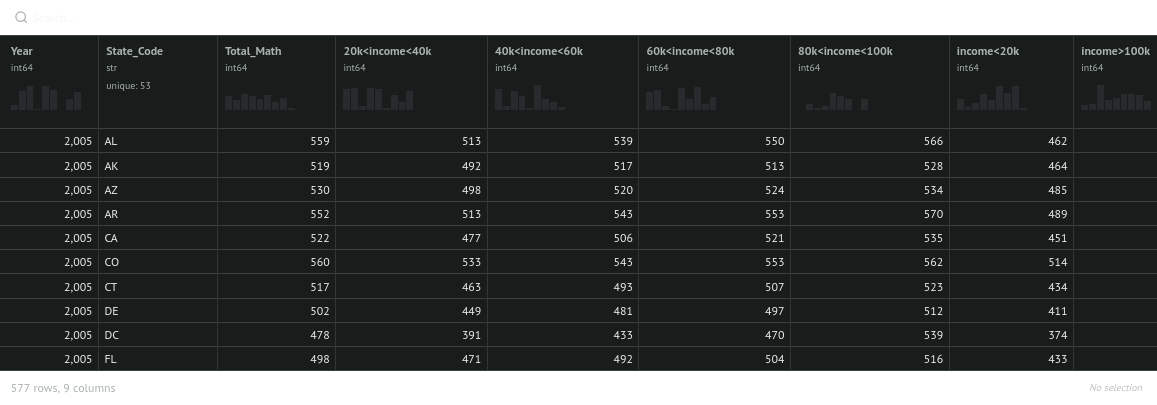

In [ ]:
df

## Find the average SAT math score for each income level, grouped and then sorted by year.

In [ ]:
mean_sat_by_year = df.groupby('Year')[df.filter(like='income').columns].mean().round(2).reset_index()

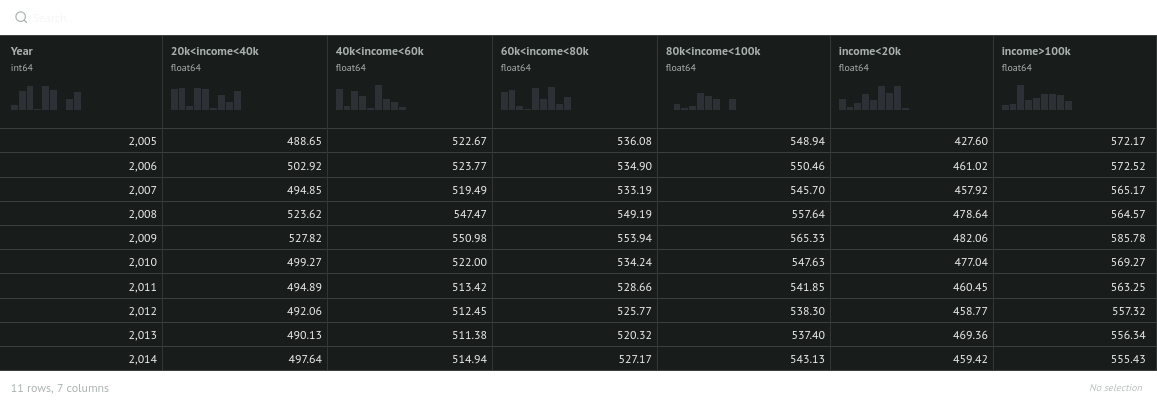

In [ ]:
mean_sat_by_year

## For each year in the data set, determine how much better each income group did, on average, than the next-poorer group of students. Do you see (just by looking at the data) any income group that did worse, in any year, than the next-poorer students?

/home/peti/Documents/Pandas_workout/.venv/lib/python3.14/site-packages/marimo/_output/formatters/pandas_formatters.py:36: UserWarning: DataFrame has integer column names. This is not supported and can lead to bugs. Please use strings for column names.
  return table(df, selection=None, pagination=None)._mime_()


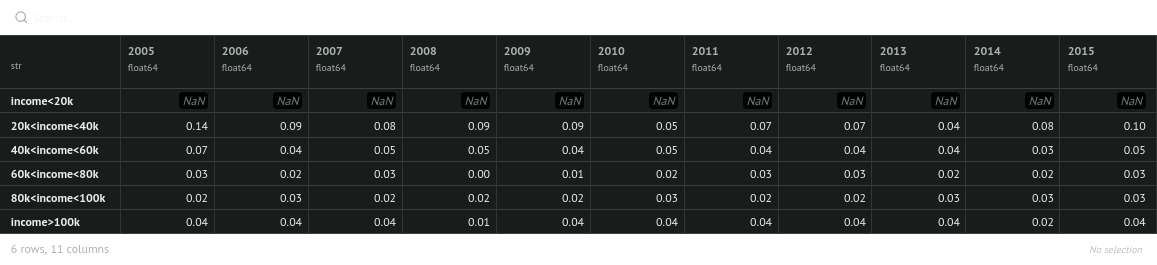

In [ ]:
desired_col_order = [
    "income<20k",
    "20k<income<40k",
    "40k<income<60k",
    "60k<income<80k",
    "80k<income<100k",
    "income>100k"
]

percentage_change_df = df.groupby('Year')[desired_col_order].mean().transpose().pct_change().round(2)

percentage_change_df

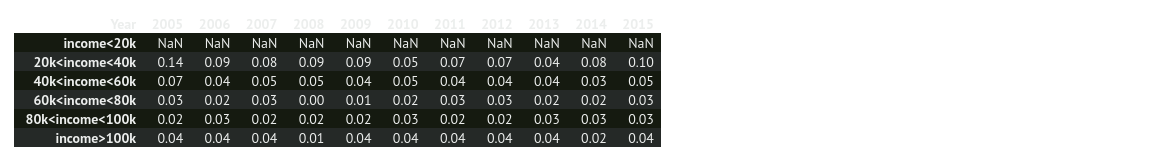

In [ ]:
# Renders the classic, static Pandas HTML table with the index intact
mo.Html(percentage_change_df.to_html())